# BGGTDM v2 — Data Exploration & API Discovery

This notebook is the starting point for the full model rebuild.

**Goals:**
1. Explore existing WR game log data (2022–2024)
2. Call `getNFLTeamRoster?getStats=true` and document exactly what comes back
3. Understand what prior-season stats are available for the early-season model path
4. Identify what TE data we still need to fetch

**Model architecture decided:**
- **Early season path** (Weeks 1–3): features from prior season stats — career_td_rate, career_targets_pg, career_yards_pg, position, draft_round
- **In-season path** (Weeks 4–18): rolling game log features (same as before but better calibrated)
- **Algorithm target**: XGBoost with isotonic calibration
- **Training**: 2022–2024 | **Holdout**: 2025
- **Positions**: WR + TE unified, with `position` as a binary feature

In [2]:
import pandas as pd
import numpy as np
import requests
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

DATA_DIR = Path('data')
API_KEY = 'REDACTED'
BASE_URL = 'https://tank01-nfl-live-in-game-real-time-statistics-nfl.p.rapidapi.com'
HEADERS = {
    'X-RapidAPI-Key': API_KEY,
    'X-RapidAPI-Host': 'tank01-nfl-live-in-game-real-time-statistics-nfl.p.rapidapi.com'
}
print('Ready')

Ready


---
## Part 1 — Existing WR Game Log Data

In [3]:
df = pd.read_csv(DATA_DIR / 'wrGameLog.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape: (5329, 40)
Columns: ['Unnamed: 0.1', 'receptions', 'receivingTargets', 'receivingYards', 'yardsPerReception', 'receivingTouchdowns', 'longReception', 'rushingAttempts', 'rushingYards', 'yardsPerRushAttempt', 'longRushing', 'rushingTouchdowns', 'fumbles', 'fumblesLost', 'fumblesForced', 'kicksBlocked', 'week', 'date', 'homeScore', 'awayScore', 'result', 'eventId', 'seasonName', 'Unnamed: 0', 'teamId', 'location', 'name', 'firstName', 'lastName', 'height', 'weight', 'athleteAge', 'draftRd', 'position', 'exp', 'headshot', 'fullName', 'seasonYr', 'seasonType', 'fPts']


,Unnamed: 0.1,receptions,receivingTargets,receivingYards,yardsPerReception,receivingTouchdowns,longReception,rushingAttempts,rushingYards,yardsPerRushAttempt,longRushing,rushingTouchdowns,fumbles,fumblesLost,fumblesForced,kicksBlocked,week,date,homeScore,awayScore,result,eventId,seasonName,Unnamed: 0,teamId,location,name,firstName,lastName,height,weight,athleteAge,draftRd,position,exp,headshot,fullName,seasonYr,seasonType,fPts
0,42,7,9,63,9.000,0,24,0,0,0.000,0,0,0,0,0,0,1,2022-09-11T20:25:00.000+00:00,21,44,L,401437653,2022 Regular Season,22,22,Arizona,Cardinals,Greg,Dortch,67,175,26,NaN,WR,4,https://a.espncdn.com/i/headshots/nfl/players/...,Greg Dortch,2022,Regular Season,6.300
1,69,6,9,65,10.800,0,18,0,0,0.000,0,0,0,0,0,0,1,2022-09-11T17:00:00.000+00:00,28,22,L,401437646,2022 Regular Season,38,22,Arizona,Cardinals,Zay,Jones,74,200,29,2.000,WR,8,https://a.espncdn.com/i/headshots/nfl/players/...,Zay Jones,2022,Regular Season,6.500
2,107,3,3,31,10.300,0,11,0,0,0.000,0,0,0,0,0,0,1,2022-09-11T17:00:00.000+00:00,20,20,T,401437637,2022 Regular Season,43,22,Arizona,Cardinals,Chris,Moore,73,200,31,4.000,WR,9,https://a.espncdn.com/i/headshots/nfl/players/...,Chris Moore,2022,Regular Season,3.100


In [4]:
# Basic dataset stats
print('Season distribution:')
print(df['seasonYr'].value_counts().sort_index())
print()
print('Position distribution:')
print(df['position'].value_counts())
print()
print('Unique players:', df['fullName'].nunique())
print('Total game-weeks:', len(df))

Season distribution:
seasonYr
2022    1967
2023    2558
2024     804
Name: count, dtype: int64

Position distribution:
position
WR    5329
Name: count, dtype: int64

Unique players: 219
Total game-weeks: 5329


In [5]:
# TD rate — the core class imbalance problem
df['scored_td'] = (df['receivingTouchdowns'] > 0).astype(int)
td_rate = df['scored_td'].mean()
print(f'Overall TD rate: {td_rate:.3f} ({td_rate*100:.1f}%)')
print(f'No TD: {(df["scored_td"]==0).sum()} rows')
print(f'TD:    {(df["scored_td"]==1).sum()} rows')
print()
print('TD rate by season:')
print(df.groupby('seasonYr')['scored_td'].mean().round(3))

Overall TD rate: 0.168 (16.8%)
No TD: 4435 rows
TD:    894 rows

TD rate by season:
seasonYr
2022   0.173
2023   0.164
2024   0.167
Name: scored_td, dtype: float64


TD rate by week:
      td_rate  n_games
week                  
1       0.161      409
2       0.185      410
3       0.174      407
4       0.134      402
5       0.159      370
6       0.186      366
7       0.161      217
8       0.212      255
9       0.147      224
10      0.187      230
11      0.164      244
12      0.172      274
13      0.185      238
14      0.160      238
15      0.156      263
16      0.181      265
17      0.133      255
18      0.164      262


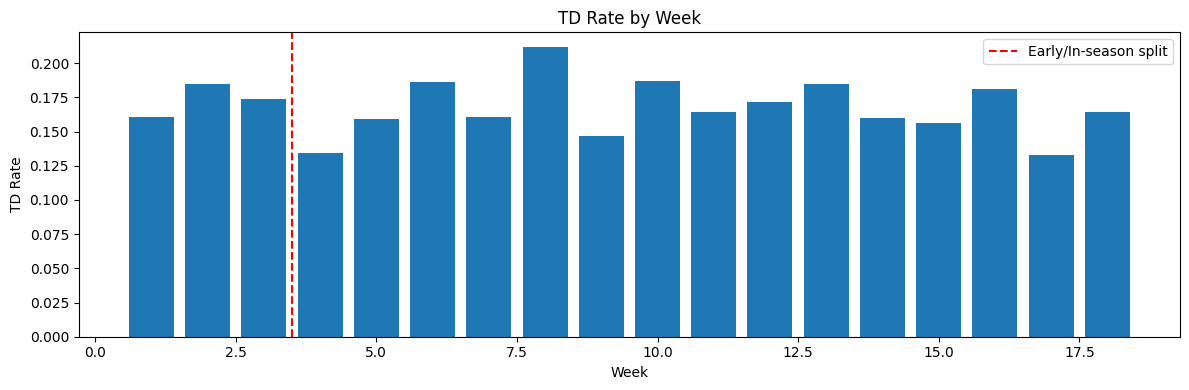

In [6]:
# TD rate by week (to understand early-season vs in-season patterns)
td_by_week = df.groupby('week')['scored_td'].agg(['mean', 'count']).round(3)
td_by_week.columns = ['td_rate', 'n_games']
print('TD rate by week:')
print(td_by_week)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(td_by_week.index, td_by_week['td_rate'])
ax.axvline(x=3.5, color='red', linestyle='--', label='Early/In-season split')
ax.set_xlabel('Week')
ax.set_ylabel('TD Rate')
ax.set_title('TD Rate by Week')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Check what draft round data looks like
print('draftRd distribution:')
print(df['draftRd'].value_counts(dropna=False).sort_index())
print()
print('Missing draftRd (undrafted):', df['draftRd'].isna().sum())

draftRd distribution:
draftRd
1.000     954
2.000    1090
3.000     642
4.000     413
5.000     416
6.000     442
7.000     219
NaN      1153
Name: count, dtype: int64

Missing draftRd (undrafted): 1153


In [8]:
# Target distribution — key for early-season features
print('Target stats:')
print(df['receivingTargets'].describe())
print()
print('Yards stats:')
print(df['receivingYards'].describe())

Target stats:
count   5329.000
mean       4.055
std        3.766
min        0.000
25%        1.000
50%        3.000
75%        6.000
max       23.000
Name: receivingTargets, dtype: float64

Yards stats:
count   5329.000
mean      32.557
std       37.629
min       -6.000
25%        0.000
50%       19.000
75%       52.000
max      265.000
Name: receivingYards, dtype: float64


---
## Part 2 — Tank01 API: `getNFLTeamRoster?getStats=true`

First task: call this for one WR-heavy team and document exactly what fields come back.
Key questions:
- What stat fields are returned?
- Are these season totals, career totals, or per-game?
- Do rookies have a stats object or is it missing/empty?
- Is there a `position` field?
- Is there draft info?

In [9]:
# Call for one team — use SF (lots of WRs/TEs)
def get_team_roster(team_abv):
    url = f'{BASE_URL}/getNFLTeamRoster'
    params = {'teamAbv': team_abv, 'getStats': 'true'}
    r = requests.get(url, headers=HEADERS, params=params)
    r.raise_for_status()
    return r.json()

sf_raw = get_team_roster('SF')
print('Top-level keys:', list(sf_raw.keys()))
body = sf_raw.get('body', sf_raw)
print('Body keys:', list(body.keys()) if isinstance(body, dict) else type(body))

Top-level keys: ['statusCode', 'body']
Body keys: ['team', 'roster']


In [10]:
# Save raw response for reference
with open(DATA_DIR / 'sf_roster_raw.json', 'w') as f:
    json.dump(sf_raw, f, indent=2)
print('Saved to data/sf_roster_raw.json')

Saved to data/sf_roster_raw.json


In [11]:
# Extract roster list
roster = body.get('roster', body) if isinstance(body, dict) else body
print(f'Roster length: {len(roster)}')
print()

# Show one player in full
print('=== FIRST PLAYER (raw) ===')
print(json.dumps(roster[0], indent=2))

Roster length: 80

=== FIRST PLAYER (raw) ===
{
  "fantasyProsLink": "https://www.fantasypros.com/nfl/players/sam-okuayinonu.php",
  "jerseyNum": "91",
  "espnName": "Sam Okuayinonu",
  "cbsLongName": "Sam Okuayinonu",
  "yahooLink": "https://sports.yahoo.com/nfl/players/34462",
  "sleeperBotID": "8540",
  "fantasyProsPlayerID": "24587",
  "lastGamePlayed": "20260117_SF@SEA",
  "espnLink": "https://www.espn.com/nfl/player/_/id/4569497/sam-okuayinonu",
  "yahooPlayerID": "34462",
  "isFreeAgent": "False",
  "pos": "DT",
  "school": "Maryland",
  "teamID": "28",
  "injury": {
    "injReturnDate": "",
    "description": "",
    "injDate": "",
    "designation": ""
  },
  "rotoWirePlayerIDFull": "sam-okuayinonu-16581",
  "rotoWirePlayerID": "16581",
  "exp": "3",
  "height": "6'1\"",
  "espnHeadshot": "https://a.espncdn.com/i/headshots/nfl/players/full/4569497.png",
  "espnID": "4569497",
  "cbsPlayerIDFull": "3123749/sam-okuayinonu/",
  "fRefID": "OkuaSa00",
  "weight": "269",
  "team": "

In [12]:
# Find WRs and TEs specifically
skill_players = [p for p in roster if p.get('pos', p.get('position', '')) in ('WR', 'TE')]
print(f'WR/TE count: {len(skill_players)}')
print()

# Show one WR and one TE
for pos in ('WR', 'TE'):
    players = [p for p in skill_players if p.get('pos', p.get('position', '')) == pos]
    if players:
        print(f'=== {pos} EXAMPLE ===')
        print(json.dumps(players[0], indent=2))
        print()

WR/TE count: 16

=== WR EXAMPLE ===
{
  "fantasyProsLink": "https://www.fantasypros.com/nfl/players/jauan-jennings.php",
  "jerseyNum": "15",
  "espnName": "Jauan Jennings",
  "cbsLongName": "Jauan Jennings",
  "yahooLink": "https://sports.yahoo.com/nfl/players/32887",
  "sleeperBotID": "7049",
  "fantasyProsPlayerID": "19590",
  "lastGamePlayed": "20260117_SF@SEA",
  "espnLink": "https://www.espn.com/nfl/player/_/id/3886598/jauan-jennings",
  "yahooPlayerID": "32887",
  "isFreeAgent": "False",
  "pos": "WR",
  "school": "Tennessee",
  "teamID": "28",
  "cbsShortName": "J. Jennings",
  "injury": {
    "injReturnDate": "",
    "description": "",
    "injDate": "",
    "designation": ""
  },
  "rotoWirePlayerIDFull": "jauan-jennings-14376",
  "rotoWirePlayerID": "14376",
  "exp": "5",
  "height": "6'3\"",
  "espnHeadshot": "https://a.espncdn.com/i/headshots/nfl/players/full/3886598.png",
  "espnID": "3886598",
  "cbsPlayerIDFull": "2180514/jauan-jennings",
  "fRefID": "JennJa00",
  "weig

In [13]:
# Inventory all stat fields that appear across skill players
all_stat_keys = set()
players_with_stats = 0
players_without_stats = 0

for p in skill_players:
    stats = p.get('stats', p.get('Receiving', None))
    if stats and isinstance(stats, dict):
        all_stat_keys.update(stats.keys())
        players_with_stats += 1
    else:
        players_without_stats += 1

print(f'Players with stats: {players_with_stats}')
print(f'Players without stats: {players_without_stats}')
print()
print('All stat keys found:')
for k in sorted(all_stat_keys):
    print(f'  {k}')

Players with stats: 11
Players without stats: 5

All stat keys found:
  Defense
  Receiving
  Rushing
  gamesPlayed
  team
  teamAbv
  teamID


In [14]:
# Key question: are stats season totals or career totals?
# Compare against known 2024 stats for a recognizable player
for p in skill_players:
    name = p.get('longName', p.get('fullName', ''))
    stats = p.get('stats', {})
    if stats and isinstance(stats, dict):
        print(f'{name}:')
        # Print any obvious counting stats
        for k in ['recTD', 'rec', 'recYds', 'targets', 'tgt', 'receivingTD', 
                   'receivingYds', 'receivingRec', 'receivingTargets']:
            if k in stats:
                print(f'  {k}: {stats[k]}')
        print()

Jake Tonges:

Jauan Jennings:

Jordan Watkins:

Malik Turner:

Demarcus Robinson:

Kendrick Bourne:

Skyy Moore:

Brayden Willis:

George Kittle:

Ricky Pearsall:

Luke Farrell:



In [15]:
# Check a rookie: look for players with 'exp' = 0 or 'rookie' in name
# Also check if draft info is in roster response
for p in skill_players:
    exp = p.get('exp', p.get('experience', None))
    if exp is not None and (str(exp) in ('0', '1', 'R')):
        name = p.get('longName', p.get('fullName', 'Unknown'))
        stats = p.get('stats', {})
        print(f'Young player: {name}, exp={exp}')
        print(f'  Has stats: {bool(stats)}')
        print(f'  Draft info keys: {[k for k in p.keys() if "draft" in k.lower()]}')
        print()

Young player: Jordan Watkins, exp=R
  Has stats: True
  Draft info keys: []

Young player: Junior Bergen, exp=R
  Has stats: False
  Draft info keys: []



In [16]:
# Full inventory of top-level player fields
all_player_keys = set()
for p in skill_players:
    all_player_keys.update(p.keys())

print('All player-level fields:')
for k in sorted(all_player_keys):
    sample = next((p.get(k) for p in skill_players if k in p), None)
    print(f'  {k}: {repr(sample)[:80]}')

All player-level fields:
  age: '26'
  bDay: '7/8/1999'
  cbsLongName: 'Jake Tonges'
  cbsPlayerIDFull: '2870660/jake-tonges'
  cbsShortName: 'J. Tonges'
  espnHeadshot: 'https://a.espncdn.com/i/headshots/nfl/players/full/4259147.png'
  espnID: '4259147'
  espnIDFull: '4259147/jake-tonges'
  espnLink: 'https://www.espn.com/nfl/player/_/id/4259147/jake-tonges'
  espnName: 'Jake Tonges'
  exp: '3'
  fRefID: 'TongJa00'
  fantasyProsLink: 'https://www.fantasypros.com/nfl/players/jake-tonges.php'
  fantasyProsPlayerID: '24778'
  height: '6\'4"'
  injury: {'injReturnDate': '20260501', 'description': "Jan 21: Tonges suffered a plantar 
  isFreeAgent: 'False'
  jerseyNum: '88'
  lastGamePlayed: '20260117_SF@SEA'
  longName: 'Jake Tonges'
  playerID: '4259147'
  pos: 'TE'
  rotoWirePlayerID: '16418'
  rotoWirePlayerIDFull: 'jake-tonges-16418'
  school: 'California'
  sleeperBotID: '8698'
  stats: {'Receiving': {'receivingTwoPointConversion': '0.0', 'receptions': '34.0', 'recT
  team: 'SF'
  tea

---
## Part 3 — Prior Season Stats Availability

For the early-season model path, we need prior-season aggregates.
Check if Tank01 returns season-specific stats or just current.

In [17]:
# Compute prior-season stats from wrGameLog.csv as a reference
# This is what we'd need to store in a prior_season_stats table
prior = df.groupby(['fullName', 'seasonYr']).agg(
    games=('week', 'count'),
    targets_pg=('receivingTargets', 'mean'),
    receptions_pg=('receptions', 'mean'),
    yards_pg=('receivingYards', 'mean'),
    tds_total=('receivingTouchdowns', 'sum'),
    td_rate=('scored_td', 'mean'),
).reset_index()

prior['targets_total'] = prior['targets_pg'] * prior['games']
prior['td_rate_per_target'] = prior['tds_total'] / prior['targets_total']

print('Prior season stats sample:')
print(prior[prior['games'] >= 8].sort_values('td_rate', ascending=False).head(20).to_string())

Prior season stats sample:
              fullName  seasonYr  games  targets_pg  receptions_pg  yards_pg  tds_total  td_rate  targets_total  td_rate_per_target
497        Tyreek Hill      2023     16      10.688          7.438   112.438         13    0.688        171.000               0.076
355         Mike Evans      2023     17       8.000          4.647    73.824         13    0.647        136.000               0.096
21   Amon-Ra St. Brown      2023     16      10.250          7.438    94.688         10    0.625        164.000               0.061
98    Courtland Sutton      2023     16       5.625          3.688    48.250         10    0.625         90.000               0.111
66         CeeDee Lamb      2023     17      10.647          7.941   102.882         12    0.588        181.000               0.066
216      Ja'Marr Chase      2022     12      11.167          7.250    87.167          9    0.583        134.000               0.067
433       Stefon Diggs      2022     16       9.6

In [18]:
# How predictive is prior-season TD rate for early-season performance?
# Build a quick correlation check: prior year td_rate vs current year td_rate
prior_shifted = prior.copy()
prior_shifted['next_yr'] = prior_shifted['seasonYr'] + 1

merged = prior.merge(
    prior_shifted[['fullName', 'next_yr', 'td_rate', 'targets_pg', 'yards_pg']].rename(
        columns={'next_yr': 'seasonYr', 'td_rate': 'prior_td_rate', 
                 'targets_pg': 'prior_targets_pg', 'yards_pg': 'prior_yards_pg'}
    ),
    on=['fullName', 'seasonYr'],
    how='inner'
)

print(f'Year-over-year pairs: {len(merged)}')
print()
print('Correlation matrix:')
print(merged[['td_rate', 'prior_td_rate', 'prior_targets_pg', 'prior_yards_pg']].corr().round(3))

Year-over-year pairs: 301

Correlation matrix:
                  td_rate  prior_td_rate  prior_targets_pg  prior_yards_pg
td_rate             1.000          0.412             0.530           0.538
prior_td_rate       0.412          1.000             0.738           0.770
prior_targets_pg    0.530          0.738             1.000           0.963
prior_yards_pg      0.538          0.770             0.963           1.000


In [19]:
# Weeks 1-3 specifically: how predictive is prior year for early weeks?
early = df[df['week'] <= 3].copy()
early_td_rate = early.groupby('fullName')['scored_td'].mean().reset_index()
early_td_rate.columns = ['fullName', 'early_td_rate']

# Merge with prior year stats (treating all seasons together for now)
check = prior[prior['games'] >= 8].merge(early_td_rate, on='fullName')
print(f'Players in early-week analysis: {len(check)}')
print()
print('Correlation of prior-season features with early-week TD rate:')
print(check[['early_td_rate', 'td_rate', 'targets_pg', 'yards_pg', 'td_rate_per_target']].corr()['early_td_rate'].round(3))

Players in early-week analysis: 289

Correlation of prior-season features with early-week TD rate:
early_td_rate        1.000
td_rate              0.637
targets_pg           0.643
yards_pg             0.650
td_rate_per_target   0.335
Name: early_td_rate, dtype: float64


---
## Part 4 — What Data We Still Need

Inventory what's missing before we can train.

In [20]:
print('=== DATA INVENTORY ===')
print()
print('HAVE:')
print(f'  WR game logs 2022-2024: {len(df)} rows, {df["fullName"].nunique()} players')
print()
print('NEED:')
print('  [ ] TE game logs 2022-2024 (same format as wrGameLog.csv)')
print('  [ ] WR game logs 2025 (holdout test set)')
print('  [ ] TE game logs 2025 (holdout test set)')
print('  [ ] Prior-season stats per player (for early-season model path)')
print('  [ ] Draft round data for all players (for rookie handling)')
print()
print('UNCLEAR (need API call to confirm):')
print('  [?] getNFLTeamRoster?getStats=true — season totals or career totals?')
print('  [?] Are there separate endpoints for historical season stats?')
print('  [?] Do rookies appear with empty stats or not at all?')

=== DATA INVENTORY ===

HAVE:
  WR game logs 2022-2024: 5329 rows, 219 players

NEED:
  [ ] TE game logs 2022-2024 (same format as wrGameLog.csv)
  [ ] WR game logs 2025 (holdout test set)
  [ ] TE game logs 2025 (holdout test set)
  [ ] Prior-season stats per player (for early-season model path)
  [ ] Draft round data for all players (for rookie handling)

UNCLEAR (need API call to confirm):
  [?] getNFLTeamRoster?getStats=true — season totals or career totals?
  [?] Are there separate endpoints for historical season stats?
  [?] Do rookies appear with empty stats or not at all?


In [21]:
# How would we fetch TE game logs?
# The wrGameLog.csv already has position column — check if TEs slipped in
print('Position values in wrGameLog.csv:')
print(df['position'].value_counts())
print()
print('If the same Tank01 endpoint was used, we need to understand the fetch logic')
print('to replicate it for TE positions.')

Position values in wrGameLog.csv:
position
WR    5329
Name: count, dtype: int64

If the same Tank01 endpoint was used, we need to understand the fetch logic
to replicate it for TE positions.


---
## Next Steps

After running this notebook:

1. **Document the roster API response** — what fields, what time period
2. **Create `02_fetch_te_data.ipynb`** — fetch TE game logs 2022-2025 via Tank01
3. **Create `03_feature_engineering_v2.ipynb`** — build the two-path feature set
4. **Create `04_model_training.ipynb`** — baseline logistic regression + XGBoost with calibration
5. **Create `05_holdout_evaluation.ipynb`** — evaluate on 2025 season as true test